In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 SalesNova Data Exploration")
print("=" * 40)

🚀 SalesNova Data Exploration


In [4]:
train_path = "../data/raw/train.csv"
store_path = "../data/raw/store.csv"

train = pd.read_csv(train_path)
store = pd.read_csv(store_path)

print("Train dataset loaded successfully!")
print("Store dataset loaded successfully!")

Train dataset loaded successfully!
Store dataset loaded successfully!


C:\Users\Aaron Kuriyan\AppData\Local\Temp\ipykernel_20084\2996490612.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(train_path)


In [5]:
print("Train dataset shape:", train.shape)
print("Store dataset shape:", store.shape)

Train dataset shape: (1017209, 9)
Store dataset shape: (1115, 10)


In [6]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
print("TRAIN COLUMNS")
print("=" * 40)

for column in train.columns:
    print(column)

print("\nSTORE COLUMNS")
print("=" * 40)

for column in store.columns:
    print(column)

TRAIN COLUMNS
Store
DayOfWeek
Date
Sales
Customers
Open
Promo
StateHoliday
SchoolHoliday

STORE COLUMNS
Store
StoreType
Assortment
CompetitionDistance
CompetitionOpenSinceMonth
CompetitionOpenSinceYear
Promo2
Promo2SinceWeek
Promo2SinceYear
PromoInterval


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [10]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [11]:
print("Missing values in train:")
print(train.isnull().sum())

print("\nMissing values in store:")
print(store.isnull().sum())

Missing values in train:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Missing values in store:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [12]:
train["Date"] = pd.to_datetime(train["Date"])

In [13]:
print(train["Date"].dtype)

datetime64[us]


In [14]:
print("First date:", train["Date"].min())
print("Last date:", train["Date"].max())

First date: 2013-01-01 00:00:00
Last date: 2015-07-31 00:00:00


In [15]:
print("Total sales:", train["Sales"].sum())
print("Average sales:", train["Sales"].mean())
print("Minimum sales:", train["Sales"].min())
print("Maximum sales:", train["Sales"].max())

Total sales: 5873180623
Average sales: 5773.818972305593
Minimum sales: 0
Maximum sales: 41551


In [16]:
print(train["Open"].value_counts())

Open
1    844392
0    172817
Name: count, dtype: int64


In [17]:
closed_sales = train[train["Open"] == 0]["Sales"]

print("Rows with stores closed:", len(closed_sales))
print("Sales recorded while closed:", closed_sales.sum())

Rows with stores closed: 172817
Sales recorded while closed: 0


In [18]:
print(train["Promo"].value_counts())

Promo
0    629129
1    388080
Name: count, dtype: int64


In [19]:
promo_sales = train.groupby("Promo")["Sales"].mean()

print(promo_sales)

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [20]:
day_sales = train.groupby("DayOfWeek")["Sales"].mean()

print(day_sales)

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


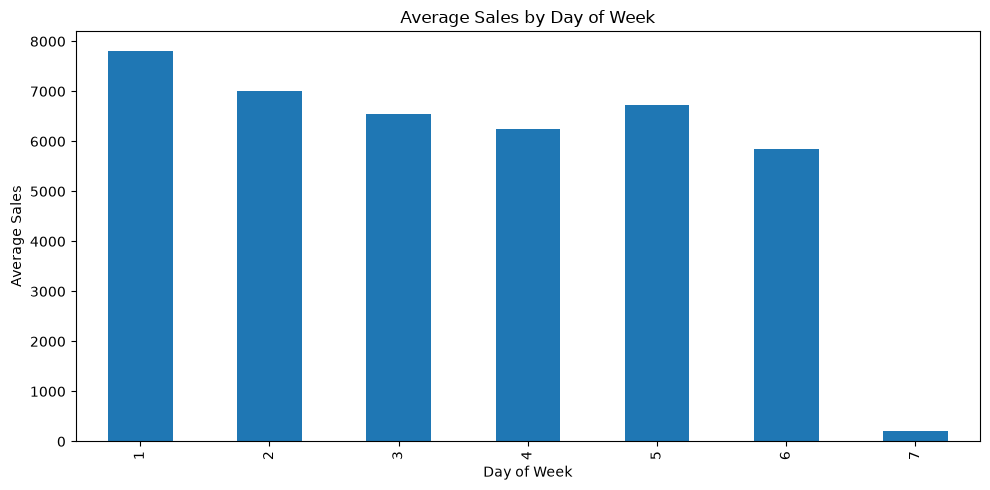

In [21]:
plt.figure(figsize=(10, 5))

day_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

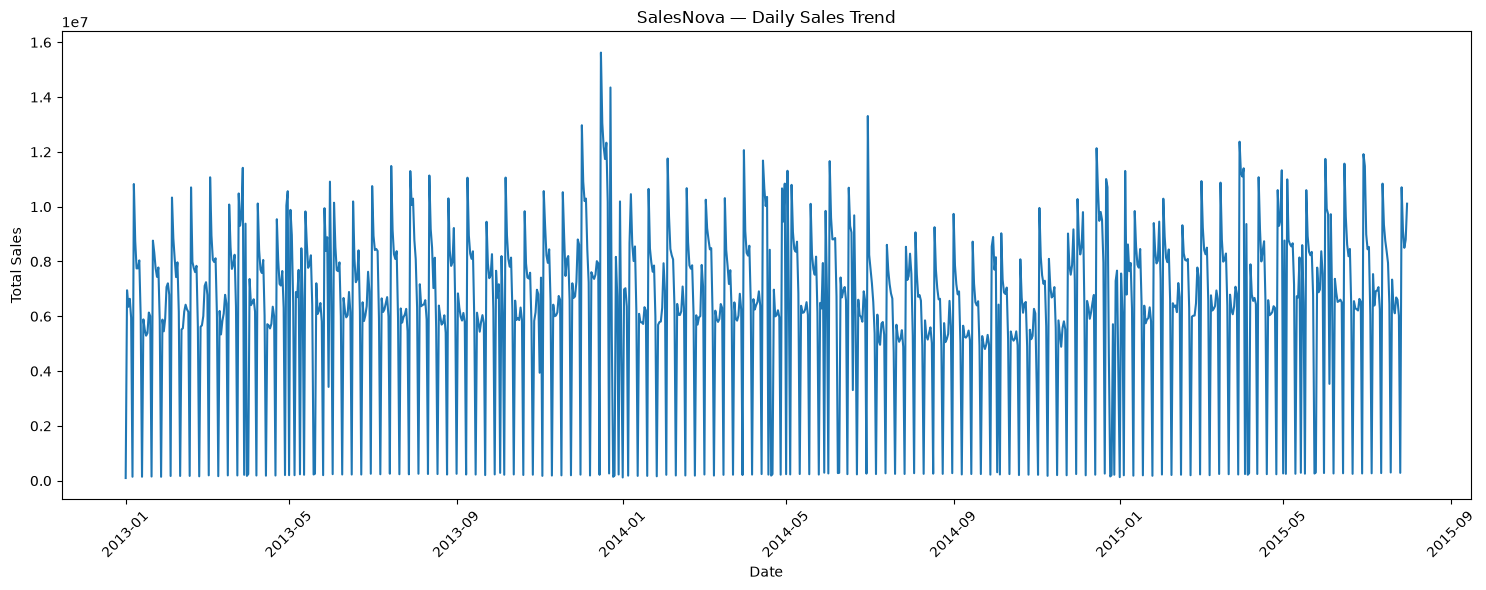

In [22]:
daily_sales = train.groupby("Date")["Sales"].sum()

plt.figure(figsize=(15, 6))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("SalesNova — Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

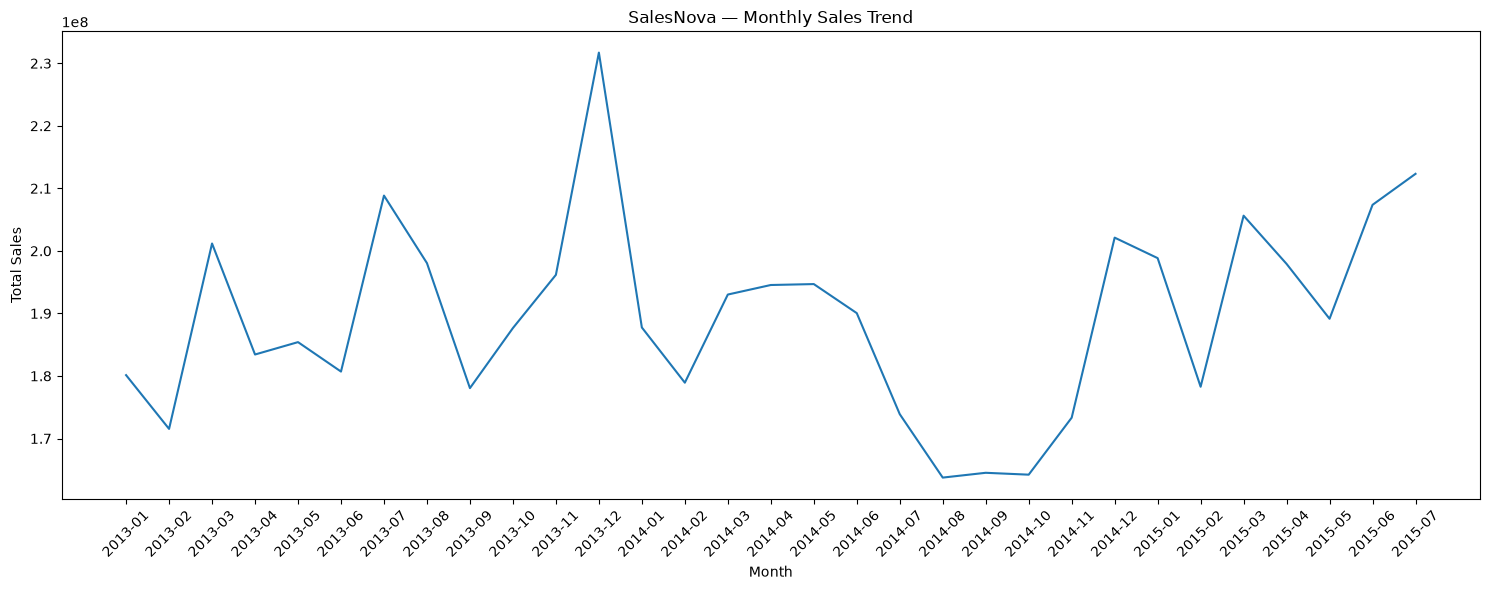

In [23]:
monthly_sales = train.groupby(
    train["Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(15, 6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("SalesNova — Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()